<a href="https://colab.research.google.com/github/KostenK-cloud/My-files-for-IS-4487/blob/main/Copy_of_IS_Project_(USE_THIS).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Walmart E-Commerce**

**Description of Organization**

The notebook should have at least the following items:

1.  Title & Project Overview
Project title
Group members’ names
Short summary of the business problem and the goals of the analysis

2. Business Problem & Context
Description of the organization and the business challenge
Why this problem matters (business impact)
Brief description of relevant industry or market factors

3. Data Sources & References
Links to datasets used (original sources, not just download locations)
Brief explanation of each dataset’s contents
Citation of at least two credible references for the business context

4. Data Acquisition & Loading
Code to load data into Python  
Any preprocessing for raw data (unzipping, merging, API calls, etc.)

5. Data Exploration (EDA)
Initial inspection  
Summary statistics
Visualizations of key trends or distributions
Identification of potential issues (missing data, outliers, inconsistent formats)

6. Data Cleaning & Preprocessing
Handling missing values, duplicates, and outliers
Encoding categorical variables
Scaling or normalization if required
Feature engineering (new calculated columns, transformations, aggregations)

7. Modeling Approach
Rationale for model selection (why you chose each algorithm)
Description of 2–3 models to be tested
Train/test split or cross-validation approach

8. Model Implementation
Code for each model (well-commented)
Hyperparameter turning (with explanations of how you attempted to improve the accuracy or fit)
Hyperparameter final settings
Any feature selection steps

9. Model Evaluation
Evaluation metrics appropriate for the problem  
Comparison of models using a summary table or chart
Interpretation of results in business terms (not just technical metrics)

10. Conclusions & Recommendations
Best model choice and why
Clear business recommendations
Suggestions for next steps or further analysis

11. Final Descriptive Charts
Create a final set of 5-6 charts, embedded in your Notebook, demonstrating the key insights from your analysis
Your charts should have consistent formatting and a clean layout
Make sure your charts are well labeled on each axis and title
NOTE: These final charts should be used in your presentation slides

1-4: Tyler

5-6: Keelan

7-9: Mia

10-11: Kosten + Keelan/Tyler if need be

# **Business Problem and Goal of Analysis**
As e-commerce growth has become increasingly more common, and, more importantly, competitive, traditional retail brands have struggled with implementing their normal business strategies onto digital platforms. Large retailers, like Walmart, must be able to increase their online revenue in order to stay competetive against companies, like Amazon, who grew from the ground up in the digital marketplace. Our goal with this analysis is to identify the biggest key drivers behind growth in e-commerce matrkets and to develop models that can discover factors that correlate strongly with profitable performance in sales.

# **Description of the Organization**
Walmart is a US-based company with one of the world's largest retailer brands, comprised of over 5,200 U.S. and over 5,600 international **physical** stores. The company's product lines span from everything to groceries, clothing, electronics, household goods, and more. Nowadays, the company has started to put an increased interest and investment in digital infrastructure and online-focused customer experiences in an effort to grow its digital retailing presence.

# **Business Challenge**
The biggest challenge for Walmart is that, despite its monumental size and abundance of resources, it is unable to, or at very least faces a very high difficulty, in maintaining high growth in ecommerce markets unlike Amazon and other companies who were started and built around the internet and e-commerce spaces. Quick online transactions, fast delivery times, and personalized product targeting have become highly scrutinized expectations for consumers shopping online. Also, Walmart has to balance this new desire to be a main player in the e-commerce world while also maintaining its traditional brick-and-mortar operations AND integrating that digitally. This could cause issues with assigning the right amount of resources to each and how they balance customer focus in physical and digital spaces. By lacking a data-driven understanding of what factors in e-commerce determine not only success, but a competitive advantage, Walmart risks wasting money, resources, time, and even the potential loss of customers to tech giants like Amazon. This analysis will address these issues and provide meaningful and actionable strategies using models that can identify the marks of e-commerce success.

# **Business Impact**
By improving its e-commerce, Walmart will be able to cement itself as not only the powerhouse in physical store shopping, but a potential main option for digital buyers too. This growth would lead to a massive increase in consumer retention rate, increase in stock value, and a huge competitive stand against, or even advantage over, leaders like Amazon.

# **Relevant Industry**
The industry relevant to this analysis is the digital retail and global e-commerce; the most well known company in this space is undoubtedly Amazon.


# **Brief explanation of dataset's**

Walmart Sales Data (**walmart_df**): Contains sales history from multiple Walmart stores along with pricing, quantities, product IDs, and more.

link: https://www.kaggle.com/datasets/shubhamsingh026/walmart-sales-data

Amazon Transaction Data (**amazon_transactions_df**): Gives a rundown of over 100,000 e-commerce transactions that detail: customer info, shipping costs, taxes, discounts, products, and pricing.

link: https://www.kaggle.com/datasets/rohiteng/amazon-sales-dataset


Citations for Business Context:
- https://retailwire.com/discussion/why-walmart-is-losing-the-e-commerce-game/
- https://www.icertias.com/journal/how-amazon-became-the-global-gold-standard-for-online-shopping



# **Data Acquisition & Loading**

Loading Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importing datasets from Kaggle

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shubhamsingh026/walmart-sales-data")

print("Path to dataset files:", path)

100%|██████████| 51.1k/51.1k [00:00<00:00, 36.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/shubhamsingh026/walmart-sales-data/versions/1


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohiteng/amazon-sales-dataset")

print("Path to dataset files:", path)

100%|██████████| 3.85M/3.85M [00:00<00:00, 219MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rohiteng/amazon-sales-dataset/versions/1


Loading as Dataframes:

In [5]:
import pandas as pd
import kagglehub
import os

# Helper function to load first CSV from a dataset path
def load_first_csv(dataset_path):
    for file in os.listdir(dataset_path):
        if file.endswith(".csv"):
            return pd.read_csv(os.path.join(dataset_path, file))
    raise FileNotFoundError("No CSV file found in dataset")

# 1. Walmart dataset → walmart_sales_df
walmart_path = kagglehub.dataset_download("shubhamsingh026/walmart-sales-data")
walmart_sales_df = load_first_csv(walmart_path)

# 2. Amazon transactions dataset → amazon_transactions_df
amazon_trans_path = kagglehub.dataset_download("rohiteng/amazon-sales-dataset")
amazon_transactions_df = load_first_csv(amazon_trans_path)

# Check results
print(walmart_sales_df.head())
print(amazon_transactions_df.head())


Using Colab cache for faster access to the 'walmart-sales-data' dataset.
Using Colab cache for faster access to the 'amazon-sales-dataset' dataset.
   Advertising_Spend  Store_Traffic  Discount_Rate  Product_Price  \
0           23973.71          11624          16.98          36.98   
1           18893.89          14277           2.99          47.32   
2           25181.51          11038          34.04          28.82   
3           32184.24          13460          18.13          45.19   
4           18126.77           5532          21.50          67.80   

   Online_Orders  Customer_Satisfaction  Competitor_Price  Seasonal_Index  \
0            913                   6.51             38.74           0.973   
1            787                   6.60             46.45           0.993   
2            705                   8.21             27.78           0.952   
3            861                   5.62             44.97           0.947   
4            824                   6.86             

Implementation Check:

In [6]:
print(walmart_sales_df.shape)
print(walmart_sales_df.head())
print(walmart_sales_df.columns)

(2000, 10)
   Advertising_Spend  Store_Traffic  Discount_Rate  Product_Price  \
0           23973.71          11624          16.98          36.98   
1           18893.89          14277           2.99          47.32   
2           25181.51          11038          34.04          28.82   
3           32184.24          13460          18.13          45.19   
4           18126.77           5532          21.50          67.80   

   Online_Orders  Customer_Satisfaction  Competitor_Price  Seasonal_Index  \
0            913                   6.51             38.74           0.973   
1            787                   6.60             46.45           0.993   
2            705                   8.21             27.78           0.952   
3            861                   5.62             44.97           0.947   
4            824                   6.86             71.59           1.112   

   Economic_Index  Monthly_Sales_Volume  
0           0.231                  1391  
1           0.731          

Loaded Correctly

# **Data Exploration (EDA)**

### This is the count of rows / columns, summary info,and first five rows of the **Walmart Sales Dataset**


In [7]:
print("These are the amounts of Rows and Columns in the Walmart Sales dataset.[Formatted as (rows, columns)]:")
print(walmart_sales_df.shape)

print("This is the summary information about the Walmart Sales Dataset:")
print(walmart_sales_df.info())

print("These are the first five rows of the dataset:")
print(walmart_sales_df.head())

These are the amounts of Rows and Columns in the Walmart Sales dataset.[Formatted as (rows, columns)]:
(2000, 10)
This is the summary information about the Walmart Sales Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Advertising_Spend      2000 non-null   float64
 1   Store_Traffic          2000 non-null   int64  
 2   Discount_Rate          2000 non-null   float64
 3   Product_Price          2000 non-null   float64
 4   Online_Orders          2000 non-null   int64  
 5   Customer_Satisfaction  2000 non-null   float64
 6   Competitor_Price       2000 non-null   float64
 7   Seasonal_Index         2000 non-null   float64
 8   Economic_Index         2000 non-null   float64
 9   Monthly_Sales_Volume   2000 non-null   int64  
dtypes: float64(7), int64(3)
memory usage: 156.4 KB
None
These are the first five rows of 

### This is the summary data for the **Walmart Sales Dataset**





In [8]:
print("Basic Summary Statistics for Walmart Sales:")
print(walmart_sales_df.describe())

Basic Summary Statistics for Walmart Sales:
       Advertising_Spend  Store_Traffic  Discount_Rate  Product_Price  \
count        2000.000000    2000.000000    2000.000000    2000.000000   
mean        20391.873850   14969.482500      17.335640      44.637830   
std          7826.158856    5021.906475      10.146835      12.482023   
min          2000.000000    1000.000000       0.010000       6.350000   
25%         15018.707500   11454.500000       8.520000      36.052500   
50%         20357.530000   14999.500000      16.995000      44.510000   
75%         25463.817500   18327.750000      26.420000      53.252500   
max         50821.850000   34631.000000      34.980000      87.350000   

       Online_Orders  Customer_Satisfaction  Competitor_Price  Seasonal_Index  \
count    2000.000000            2000.000000       2000.000000     2000.000000   
mean      801.400000               7.526925         45.585580        1.000576   
std        57.864464               1.104630         13.

### This is the count of rows / columns, summary info,and first five rows of the **Amazon Transactions Dataset**

In [9]:
print("These are the amounts of Rows and Columns in the Amazon Transactions dataset.[Formatted as (rows, columns)]:")
print(amazon_transactions_df.shape)

print("This is the summary information about the Amazon Transactions Dataset:")
print(amazon_transactions_df.info())

print("These are the first five rows of the dataset:")
print(amazon_transactions_df.head())

These are the amounts of Rows and Columns in the Amazon Transactions dataset.[Formatted as (rows, columns)]:
(100000, 20)
This is the summary information about the Amazon Transactions Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  object 
 1   OrderDate      100000 non-null  object 
 2   CustomerID     100000 non-null  object 
 3   CustomerName   100000 non-null  object 
 4   ProductID      100000 non-null  object 
 5   ProductName    100000 non-null  object 
 6   Category       100000 non-null  object 
 7   Brand          100000 non-null  object 
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    10

### This is the summary data for the **Amazon Transactions Dataset**

In [10]:
print("Basic Summary Statistics for Amazon Transactions:")
print(amazon_transactions_df.describe())

Basic Summary Statistics for Amazon Transactions:
            Quantity      UnitPrice       Discount            Tax  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean        3.001400     302.905748       0.074226      68.468902   
std         1.413548     171.840797       0.082583      74.131180   
min         1.000000       5.000000       0.000000       0.000000   
25%         2.000000     154.190000       0.000000      15.920000   
50%         3.000000     303.070000       0.050000      45.250000   
75%         4.000000     451.500000       0.100000      96.060000   
max         5.000000     599.990000       0.300000     538.460000   

        ShippingCost    TotalAmount  
count  100000.000000  100000.000000  
mean        7.406660     918.256479  
std         4.324057     724.508332  
min         0.000000       4.270000  
25%         3.680000     340.890000  
50%         7.300000     714.315000  
75%        11.150000    1349.765000  
max        15.000000    

# *VISUALIZATIONS*

---



### **Histograms of different values for Walmart Sales**

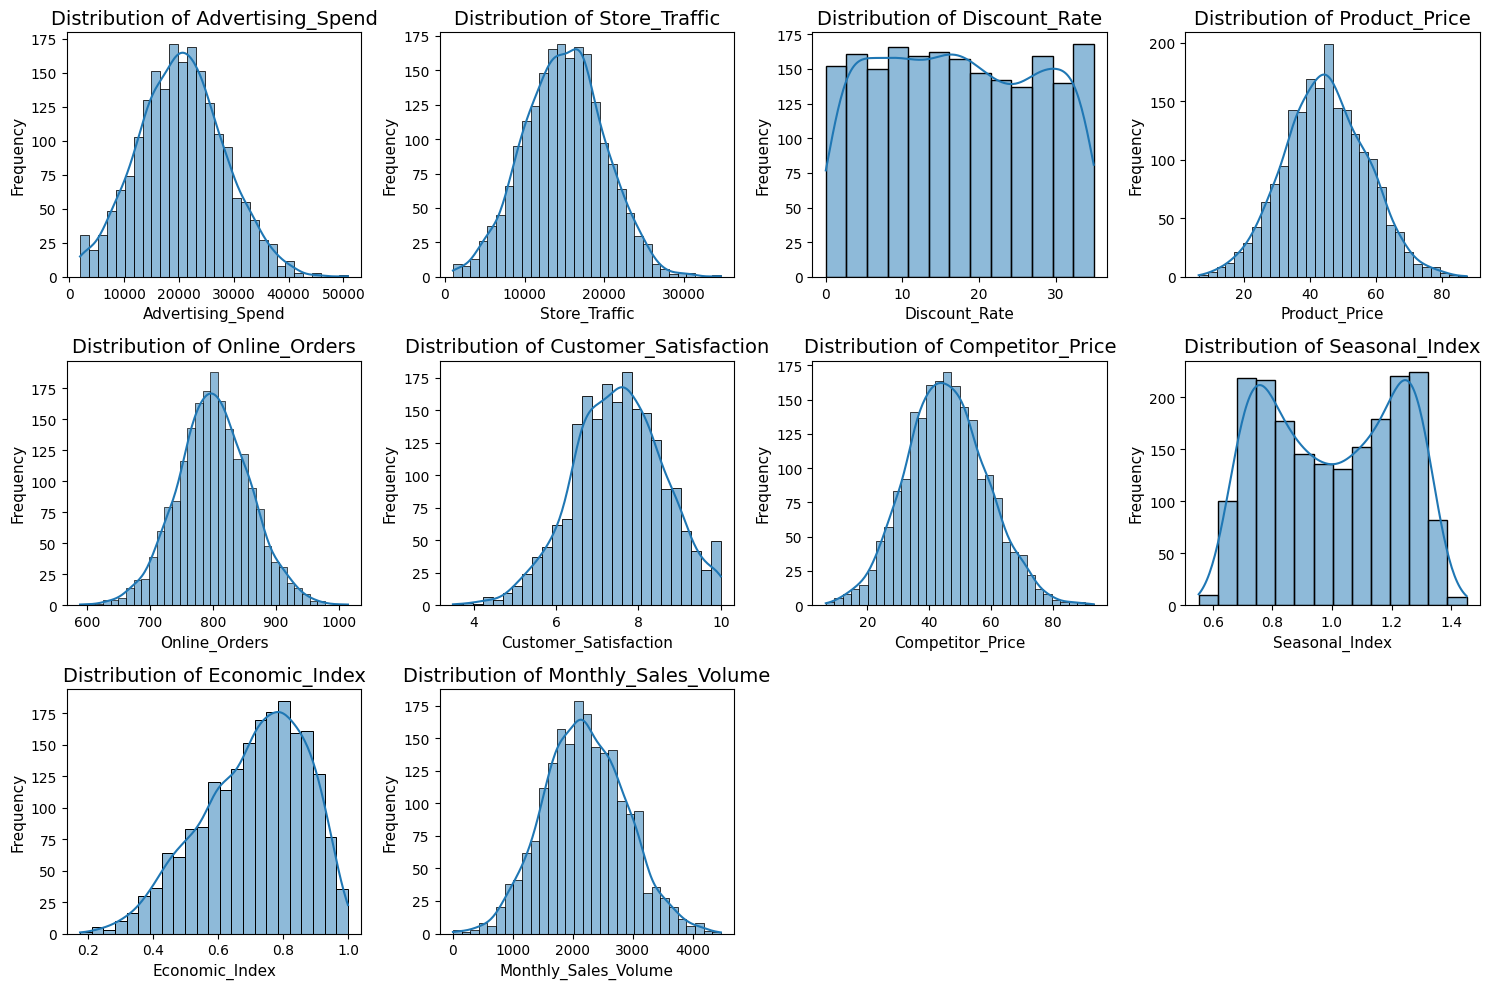

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns from walmart_sales_df
numerical_cols = walmart_sales_df.select_dtypes(include=['number']).columns

# Create histograms for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1)  # Adjust subplot grid as needed
    sns.histplot(walmart_sales_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### **Box Plots for Walmart Sales Dataset**

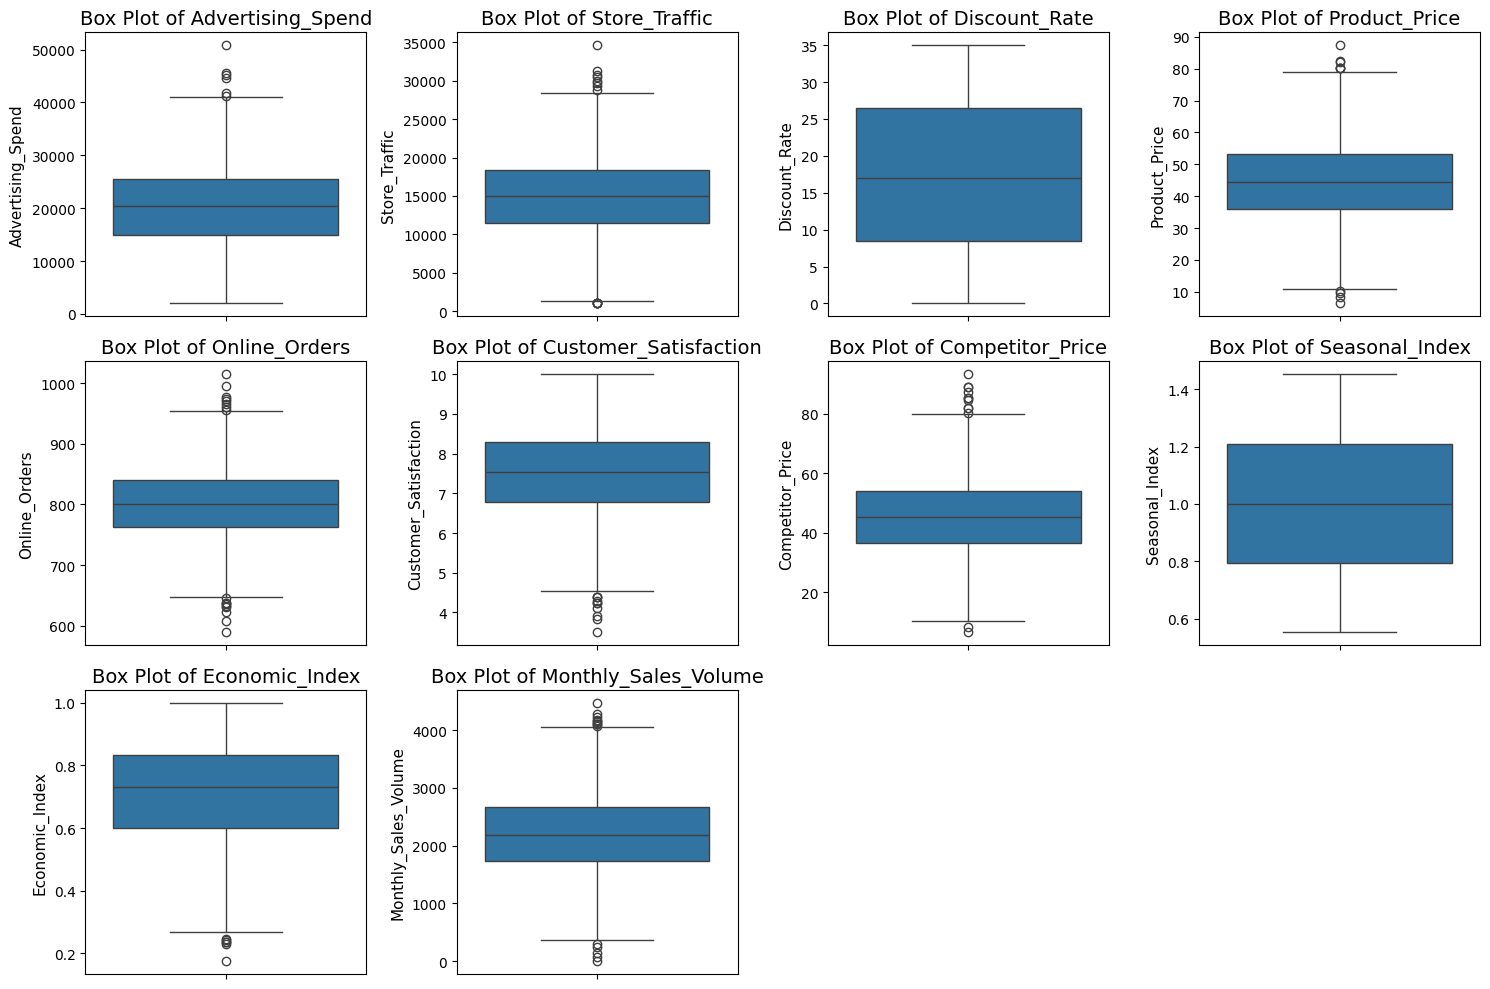

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns from walmart_sales_df
numerical_cols = walmart_sales_df.select_dtypes(include=['number']).columns

# Create box plots for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1)  # Adjust subplot grid as needed
    sns.boxplot(y=walmart_sales_df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### **Correlation Heatmap for Walmart Sales Dataset**

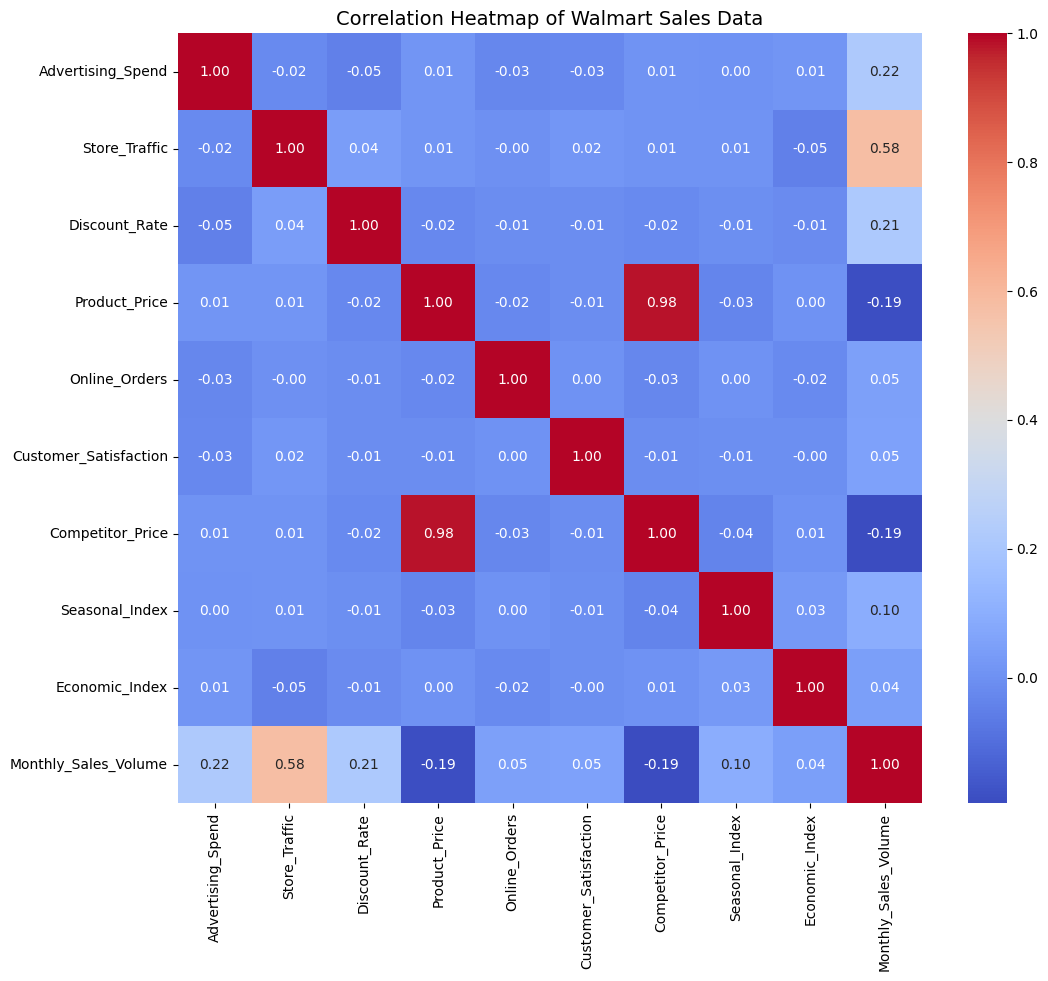

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = walmart_sales_df.corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Walmart Sales Data')
plt.show()

### **Visualizations for Amazon Transactions Dataset**

#### **Histograms of numerical values for Amazon Transactions**

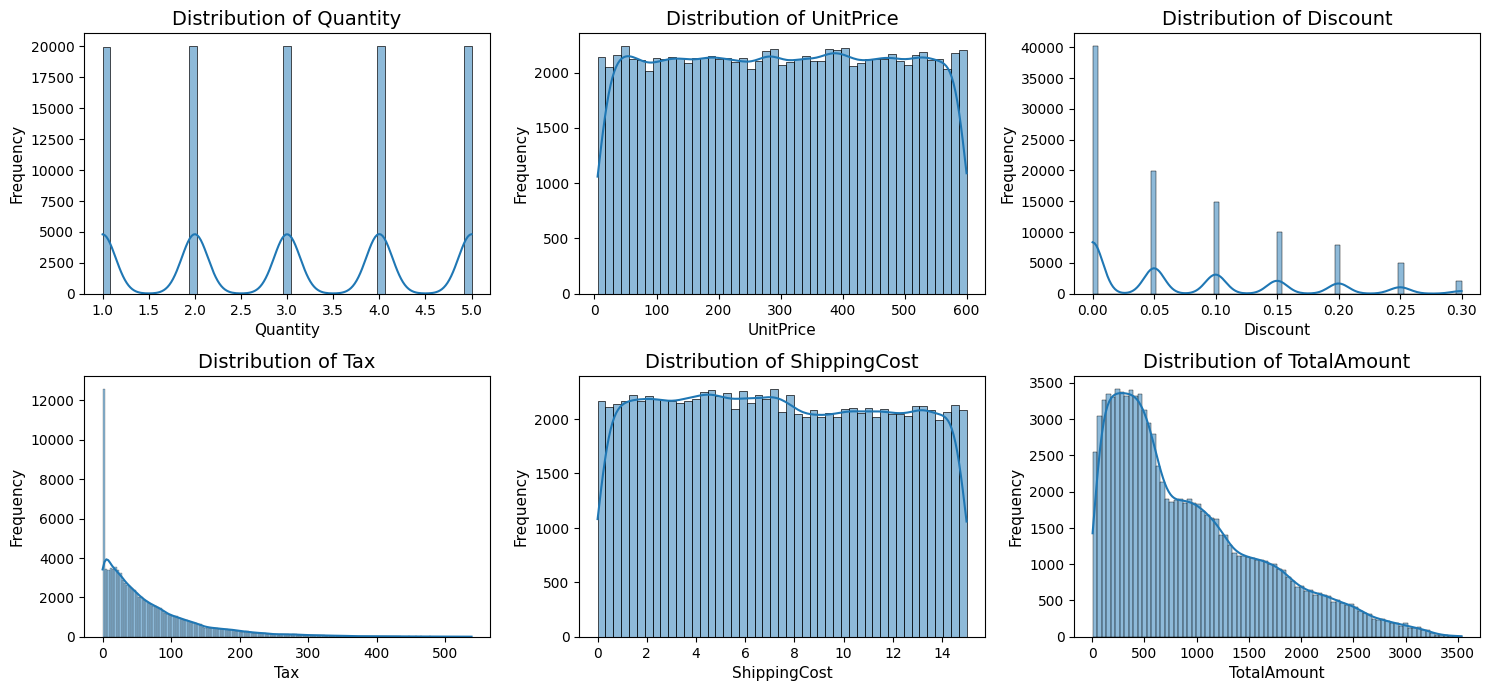

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns from amazon_transactions_df
numerical_cols_amazon_trans = amazon_transactions_df.select_dtypes(include=['number']).columns

# Create histograms for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_amazon_trans):
    plt.subplot(3, 3, i + 1)  # Adjust subplot grid as needed
    sns.histplot(amazon_transactions_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#### **Box Plots for Amazon Transactions Dataset**

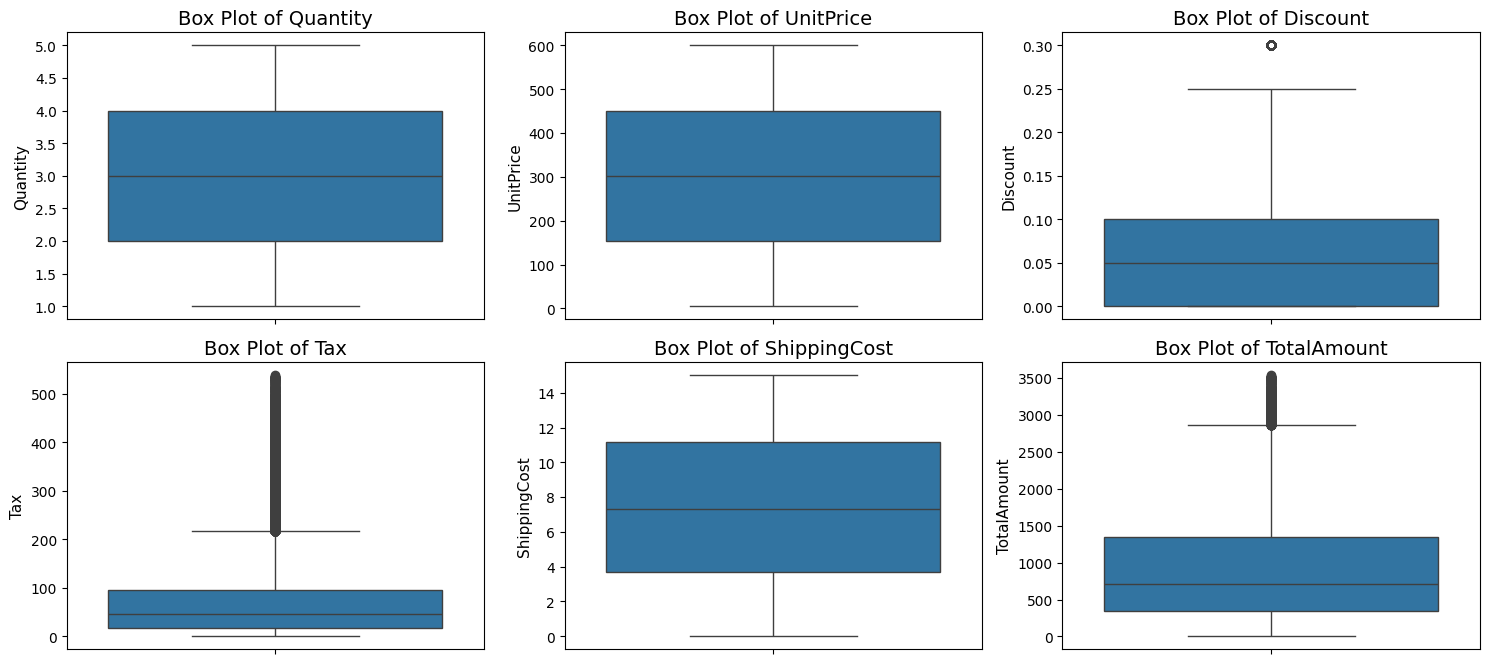

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns from amazon_transactions_df
numerical_cols_amazon_trans = amazon_transactions_df.select_dtypes(include=['number']).columns

# Create box plots for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_amazon_trans):
    plt.subplot(3, 3, i + 1)  # Adjust subplot grid as needed
    sns.boxplot(y=amazon_transactions_df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

#### **Correlation Heatmap for Amazon Transactions Dataset**

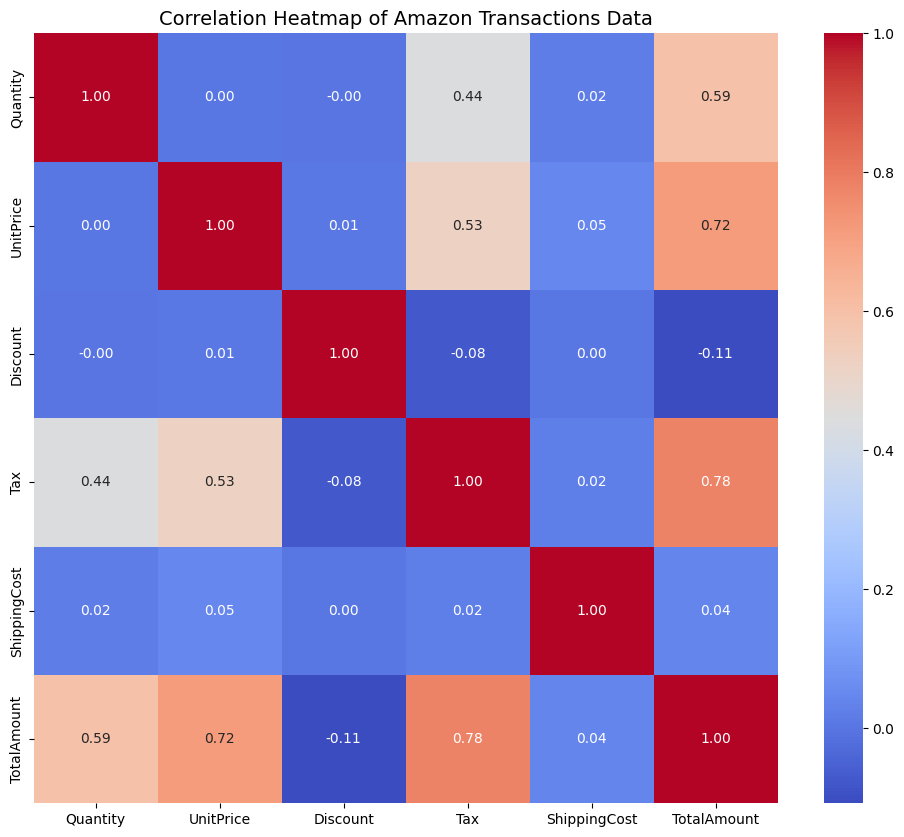

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix_amazon_trans = amazon_transactions_df.corr(numeric_only=True)

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_amazon_trans, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Amazon Transactions Data')
plt.show()

### **Identifying Possible Issues with Datasets**

### *Walmart Sales*

In [17]:
# --- Identification of Potential Issues for Walmart Sales Data ---

print("### 1. Missing Data Analysis")
print("As previously confirmed with `walmart_sales_df.isnull().sum()`:")
print(walmart_sales_df.isnull().sum())
print("Conclusion: There are no missing values in the Walmart Sales Dataset.\n")

print("### 2. Outlier Identification")
print("From the previously generated box plots, several columns show potential outliers:")
print("- `Advertising_Spend`: Appears to have some high-end outliers.")
print("- `Product_Price`: Shows a few high-end outliers.")
print("- `Store_Traffic`: Exhibits a few high-end outliers.")
print("- `Monthly_Sales_Volume`: Has a notable number of high-end outliers.")
print("\nLet's programmatically identify outliers using the IQR method for numerical columns.")

# Identify numerical columns for outlier detection
numerical_cols = walmart_sales_df.select_dtypes(include=['number']).columns

for col in numerical_cols:
    Q1 = walmart_sales_df[col].quantile(0.25)
    Q3 = walmart_sales_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = walmart_sales_df[(walmart_sales_df[col] < lower_bound) | (walmart_sales_df[col] > upper_bound)]
    if not outliers.empty:
        print(f"Column '{col}': {len(outliers)} outliers detected (min: {outliers[col].min():.2f}, max: {outliers[col].max():.2f})")
    else:
        print(f"Column '{col}': No significant outliers detected by IQR method.")
print("\nThese outliers will need to be addressed during data cleaning and preprocessing.\n")

print("### 3. Inconsistent Formats")
print("From the `info()` output, all columns in `walmart_sales_df` are of numerical types (float64 or int64) and have no non-null entries, indicating consistent data types across the dataset.")
print("No apparent inconsistent formats were identified at this stage.")

# Display data types again for quick reference
print("\nData Types for Walmart Sales Dataset:")
print(walmart_sales_df.dtypes)

### 1. Missing Data Analysis
As previously confirmed with `walmart_sales_df.isnull().sum()`:
Advertising_Spend        0
Store_Traffic            0
Discount_Rate            0
Product_Price            0
Online_Orders            0
Customer_Satisfaction    0
Competitor_Price         0
Seasonal_Index           0
Economic_Index           0
Monthly_Sales_Volume     0
dtype: int64
Conclusion: There are no missing values in the Walmart Sales Dataset.

### 2. Outlier Identification
From the previously generated box plots, several columns show potential outliers:
- `Advertising_Spend`: Appears to have some high-end outliers.
- `Product_Price`: Shows a few high-end outliers.
- `Store_Traffic`: Exhibits a few high-end outliers.
- `Monthly_Sales_Volume`: Has a notable number of high-end outliers.

Let's programmatically identify outliers using the IQR method for numerical columns.
Column 'Advertising_Spend': 6 outliers detected (min: 41154.75, max: 50821.85)
Column 'Store_Traffic': 13 outliers detec

### *Amazon Transactions*

In [18]:
# --- Identification of Potential Issues for Amazon Transactions Data ---

print("### 1. Missing Data Analysis")
print(amazon_transactions_df.isnull().sum())
print("Conclusion: There are no missing values in the Amazon Transactions Dataset.\n")

print("### 2. Outlier Identification")
print("From the previously generated box plots, several numerical columns in the Amazon Transactions dataset show potential outliers. Let's programmatically identify them using the IQR method.")

numerical_cols_amazon_trans = amazon_transactions_df.select_dtypes(include=['number']).columns

for col in numerical_cols_amazon_trans:
    Q1 = amazon_transactions_df[col].quantile(0.25)
    Q3 = amazon_transactions_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = amazon_transactions_df[(amazon_transactions_df[col] < lower_bound) | (amazon_transactions_df[col] > upper_bound)]
    if not outliers.empty:
        print(f"Column '{col}': {len(outliers)} outliers detected (min: {outliers[col].min():.2f}, max: {outliers[col].max():.2f})")
    else:
        print(f"Column '{col}': No significant outliers detected by IQR method.")
print("\nThese outliers will need to be addressed during data cleaning and preprocessing.\n")

print("### 3. Inconsistent Formats")
print("From the `info()` output, the Amazon Transactions Dataset contains a mix of numerical and object (string) types. The 'OrderDate' column is currently an object type and will need to be converted to datetime during preprocessing.")
print("No other apparent inconsistent formats were identified at this stage.")

print("\nData Types for Amazon Transactions Dataset:")
print(amazon_transactions_df.dtypes)

### 1. Missing Data Analysis
OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
SellerID         0
dtype: int64
Conclusion: There are no missing values in the Amazon Transactions Dataset.

### 2. Outlier Identification
From the previously generated box plots, several numerical columns in the Amazon Transactions dataset show potential outliers. Let's programmatically identify them using the IQR method.
Column 'Quantity': No significant outliers detected by IQR method.
Column 'UnitPrice': No significant outliers detected by IQR method.
Column 'Discount': 1989 outliers detected (min: 0.30, max: 0.30)
Column 'Tax': 5109 outliers detected (min: 216.28, max: 538.46)
Column 'ShippingCost'

# **Data Cleaning & Preprocessing**

### Handling missing values, duplicates, and outliers in **Walmart Sales Dataset**

In [19]:
# --- Handling missing values, duplicates, and outliers in Walmart Sales Dataset ---

print("### 1. Handling Missing Values")
# As previously identified, there are no missing values in walmart_sales_df.
print("No missing values found in walmart_sales_df. No action required.\n")

print("### 2. Handling Duplicates")
initial_rows = walmart_sales_df.shape[0]
walmart_sales_df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - walmart_sales_df.shape[0]
if duplicates_removed > 0:
    print(f"{duplicates_removed} duplicate rows removed from walmart_sales_df.\n")
else:
    print("No duplicate rows found in walmart_sales_df. No action required.\n")

print("### 3. Handling Outliers (Capping using IQR Method)")
# Outliers were identified in: Advertising_Spend, Store_Traffic, Product_Price, Online_Orders, Customer_Satisfaction, Competitor_Price, Economic_Index, Monthly_Sales_Volume
# We will cap these outliers to the IQR bounds to minimize their impact.

numerical_cols_with_outliers = [
    'Advertising_Spend', 'Store_Traffic', 'Product_Price', 'Online_Orders',
    'Customer_Satisfaction', 'Competitor_Price', 'Economic_Index', 'Monthly_Sales_Volume'
]

for col in numerical_cols_with_outliers:
    Q1 = walmart_sales_df[col].quantile(0.25)
    Q3 = walmart_sales_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers
    walmart_sales_df[col] = np.where(walmart_sales_df[col] < lower_bound, lower_bound, walmart_sales_df[col])
    walmart_sales_df[col] = np.where(walmart_sales_df[col] > upper_bound, upper_bound, walmart_sales_df[col])
    print(f"Outliers in '{col}' have been capped using the IQR method.")

print("\nWalmart Sales Dataset cleaning and outlier handling complete.")


### 1. Handling Missing Values
No missing values found in walmart_sales_df. No action required.

### 2. Handling Duplicates
No duplicate rows found in walmart_sales_df. No action required.

### 3. Handling Outliers (Capping using IQR Method)
Outliers in 'Advertising_Spend' have been capped using the IQR method.
Outliers in 'Store_Traffic' have been capped using the IQR method.
Outliers in 'Product_Price' have been capped using the IQR method.
Outliers in 'Online_Orders' have been capped using the IQR method.
Outliers in 'Customer_Satisfaction' have been capped using the IQR method.
Outliers in 'Competitor_Price' have been capped using the IQR method.
Outliers in 'Economic_Index' have been capped using the IQR method.
Outliers in 'Monthly_Sales_Volume' have been capped using the IQR method.

Walmart Sales Dataset cleaning and outlier handling complete.


### Handling missing values, duplicates, and outliers, and data type conversion in **Amazon Transactions Dataset**

In [20]:
# --- Handling missing values, duplicates, and outliers in Amazon Transactions Dataset ---

print("### 1. Handling Missing Values")
# As previously identified, there are no missing values in amazon_transactions_df.
print("No missing values found in amazon_transactions_df. No action required.\n")

print("### 2. Handling Duplicates")
initial_rows_trans = amazon_transactions_df.shape[0]
amazon_transactions_df.drop_duplicates(inplace=True)
duplicates_removed_trans = initial_rows_trans - amazon_transactions_df.shape[0]
if duplicates_removed_trans > 0:
    print(f"{duplicates_removed_trans} duplicate rows removed from amazon_transactions_df.\n")
else:
    print("No duplicate rows found in amazon_transactions_df. No action required.\n")

print("### 3. Handling Outliers (Capping using IQR Method)")
# Outliers were identified in: Discount, Tax, TotalAmount

numerical_cols_with_outliers_trans = [
    'Discount', 'Tax', 'TotalAmount'
]

for col in numerical_cols_with_outliers_trans:
    Q1 = amazon_transactions_df[col].quantile(0.25)
    Q3 = amazon_transactions_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers
    amazon_transactions_df[col] = np.where(amazon_transactions_df[col] < lower_bound, lower_bound, amazon_transactions_df[col])
    amazon_transactions_df[col] = np.where(amazon_transactions_df[col] > upper_bound, upper_bound, amazon_transactions_df[col])
    print(f"Outliers in '{col}' have been capped using the IQR method.")

print("\n### 4. Converting 'OrderDate' to Datetime")
amazon_transactions_df['OrderDate'] = pd.to_datetime(amazon_transactions_df['OrderDate'])
print("'OrderDate' column in amazon_transactions_df converted to datetime.\n")

print("Amazon Transactions Dataset cleaning and preprocessing complete.")

### 1. Handling Missing Values
No missing values found in amazon_transactions_df. No action required.

### 2. Handling Duplicates
No duplicate rows found in amazon_transactions_df. No action required.

### 3. Handling Outliers (Capping using IQR Method)
Outliers in 'Discount' have been capped using the IQR method.
Outliers in 'Tax' have been capped using the IQR method.
Outliers in 'TotalAmount' have been capped using the IQR method.

### 4. Converting 'OrderDate' to Datetime
'OrderDate' column in amazon_transactions_df converted to datetime.

Amazon Transactions Dataset cleaning and preprocessing complete.


### Encoding Categorical Variables in **Amazon Transactions Dataset**

In [21]:
# Identify categorical columns for one-hot encoding (excluding identifiers and already processed date column)
categorical_cols_amazon_trans = [
    'Category', 'Brand', 'PaymentMethod', 'OrderStatus', 'City', 'State', 'Country'
]

# Before encoding, let's check the number of unique values for each to anticipate the new column count
print("Unique values count for categorical columns in amazon_transactions_df:")
for col in categorical_cols_amazon_trans:
    print(f"- {col}: {amazon_transactions_df[col].nunique()} unique values")

# Apply one-hot encoding
amazon_transactions_df_encoded = pd.get_dummies(amazon_transactions_df, columns=categorical_cols_amazon_trans, drop_first=True)

print("\nOriginal shape of amazon_transactions_df:", amazon_transactions_df.shape)
print("New shape of amazon_transactions_df after one-hot encoding:", amazon_transactions_df_encoded.shape)
print("\nFirst 5 rows of the encoded Amazon Transactions Dataset:")
display(amazon_transactions_df_encoded.head())

Unique values count for categorical columns in amazon_transactions_df:
- Category: 6 unique values
- Brand: 10 unique values
- PaymentMethod: 6 unique values
- OrderStatus: 5 unique values
- City: 20 unique values
- State: 13 unique values
- Country: 5 unique values

Original shape of amazon_transactions_df: (100000, 20)
New shape of amazon_transactions_df after one-hot encoding: (100000, 71)

First 5 rows of the encoded Amazon Transactions Dataset:


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Quantity,UnitPrice,Discount,Tax,...,State_NC,State_NY,State_OH,State_PA,State_TX,State_WA,Country_Canada,Country_India,Country_United Kingdom,Country_United States
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,3,106.59,0.00,0.00,...,False,False,False,False,False,False,False,True,False,False
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,1,251.37,0.05,19.10,...,False,False,False,False,True,False,False,False,False,True
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,3,35.03,0.10,7.57,...,False,False,False,False,True,False,False,False,False,True
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,5,33.58,0.15,11.42,...,True,False,False,False,False,False,False,True,False,False
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,2,515.64,0.25,38.67,...,False,False,False,False,True,False,True,False,False,False


### **Walmart Sales did not require any hot-encoding*

### Scaling Numerical Features for Walmart Sales Dataset

In [22]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling in walmart_sales_df
numerical_cols_walmart = walmart_sales_df.select_dtypes(include=['number']).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling
walmart_sales_scaled_df = walmart_sales_df.copy()
walmart_sales_scaled_df[numerical_cols_walmart] = scaler.fit_transform(walmart_sales_scaled_df[numerical_cols_walmart])

print("Walmart Sales Dataset after scaling numerical features:")
display(walmart_sales_scaled_df.head())

Walmart Sales Dataset after scaling numerical features:


,Advertising_Spend,Store_Traffic,Discount_Rate,Product_Price,Online_Orders,Customer_Satisfaction,Competitor_Price,Seasonal_Index,Economic_Index,Monthly_Sales_Volume
0,0.461218,-0.668212,-0.035058,-0.614982,1.947218,-0.926940,-0.526713,-0.125569,-2.907835,-1.193129
1,-0.190866,-0.137111,-1.414158,0.216042,-0.251446,-0.845047,0.068721,-0.034499,0.133531,-0.942945
2,0.616260,-0.785522,1.646675,-1.270799,-1.682322,0.619932,-1.373142,-0.221192,-1.488955,-0.208581
3,1.515184,-0.300666,0.078306,0.044854,1.039833,-1.736773,-0.045578,-0.243960,-0.553640,0.655291
4,-0.289339,-1.887761,0.410512,1.862015,0.394193,-0.608467,2.010255,0.507365,1.316991,-1.409465


### Scaling Numerical Features for Amazon Transactions Dataset

In [23]:
# Identify numerical columns for scaling in amazon_transactions_df_encoded
# Exclude 'OrderDate' as it's a datetime object and identifiers like OrderID, CustomerID, ProductID, SellerID.
numerical_cols_amazon_trans_encoded = amazon_transactions_df_encoded.select_dtypes(include=['number']).columns

# Initialize StandardScaler
scaler_amazon_trans = StandardScaler()

# Apply scaling
amazon_transactions_scaled_df = amazon_transactions_df_encoded.copy()
amazon_transactions_scaled_df[numerical_cols_amazon_trans_encoded] = scaler_amazon_trans.fit_transform(amazon_transactions_scaled_df[numerical_cols_amazon_trans_encoded])

print("Amazon Transactions Dataset after scaling numerical features:")
display(amazon_transactions_scaled_df.head())

Amazon Transactions Dataset after scaling numerical features:


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Quantity,UnitPrice,Discount,Tax,...,State_NC,State_NY,State_OH,State_PA,State_TX,State_WA,Country_Canada,Country_India,Country_United Kingdom,Country_United States
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,-0.000990,-1.142434,-0.913997,-1.045539,...,False,False,False,False,False,False,False,True,False,False
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,-1.415877,-0.299906,-0.289951,-0.736488,...,False,False,False,False,True,False,False,False,False,True
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,-0.000990,-1.558868,0.334096,-0.923051,...,False,False,False,False,True,False,False,False,False,True
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,1.413896,-1.567306,0.958142,-0.860756,...,True,False,False,False,False,False,False,True,False,False
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,-0.708434,1.237979,2.206235,-0.419831,...,False,False,False,False,True,False,True,False,False,False


## **Modeling Approach: Linear Regression (Baseline)**

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

### **Linear Regression for Walmart Sales Dataset**

In [25]:
# Define features (X) and target (y) for Walmart Sales
X_walmart = walmart_sales_scaled_df.drop('Monthly_Sales_Volume', axis=1)
y_walmart = walmart_sales_scaled_df['Monthly_Sales_Volume']

# Split the data into training and testing sets
X_train_walmart, X_test_walmart, y_train_walmart, y_test_walmart = train_test_split(X_walmart, y_walmart, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
linear_model_walmart = LinearRegression()
linear_model_walmart.fit(X_train_walmart, y_train_walmart)

# Make predictions on the test set
y_pred_walmart = linear_model_walmart.predict(X_test_walmart)

# Evaluate the model
mse_walmart = mean_squared_error(y_test_walmart, y_pred_walmart)
r2_walmart = r2_score(y_test_walmart, y_pred_walmart)

print(f"Walmart Sales Linear Regression Model Performance:")
print(f"Mean Squared Error (MSE): {mse_walmart:.4f}")
print(f"R-squared (R2): {r2_walmart:.4f}")

Walmart Sales Linear Regression Model Performance:
Mean Squared Error (MSE): 0.5899
R-squared (R2): 0.4434


### **Linear Regression for Amazon Transactions Dataset**

In [26]:
# Define features (X) and target (y) for Amazon Transactions
# Exclude non-numerical and identifier columns
X_amazon_trans = amazon_transactions_scaled_df.drop(columns=['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID', 'ProductName', 'SellerID', 'TotalAmount'])
y_amazon_trans = amazon_transactions_scaled_df['TotalAmount']

# Split the data into training and testing sets
X_train_amazon_trans, X_test_amazon_trans, y_train_amazon_trans, y_test_amazon_trans = train_test_split(X_amazon_trans, y_amazon_trans, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
linear_model_amazon_trans = LinearRegression()
linear_model_amazon_trans.fit(X_train_amazon_trans, y_train_amazon_trans)

# Make predictions on the test set
y_pred_amazon_trans = linear_model_amazon_trans.predict(X_test_amazon_trans)

# Evaluate the model
mse_amazon_trans = mean_squared_error(y_test_amazon_trans, y_pred_amazon_trans)
r2_amazon_trans = r2_score(y_test_amazon_trans, y_pred_amazon_trans)

print(f"Amazon Transactions Linear Regression Model Performance:")
print(f"Mean Squared Error (MSE): {mse_amazon_trans:.4f}")
print(f"R-squared (R2): {r2_amazon_trans:.4f}")

Amazon Transactions Linear Regression Model Performance:
Mean Squared Error (MSE): 0.0934
R-squared (R2): 0.9061


### Feature Engineering for **Walmart Sales Dataset**

In [27]:
# Create 'Effective Price' for walmart_sales_scaled_df
# Assuming 'Product_Price' is the base price and 'Discount_Rate' is a percentage discount
walmart_sales_scaled_df['Effective_Price'] = walmart_sales_scaled_df['Product_Price'] * (1 - (walmart_sales_scaled_df['Discount_Rate'] / 100))

# Create 'Advertising to Traffic Ratio' for walmart_sales_scaled_df
# To avoid division by zero, we can add a small constant to 'Store_Traffic' or handle it with a conditional statement
walmart_sales_scaled_df['Advertising_to_Traffic_Ratio'] = walmart_sales_scaled_df['Advertising_Spend'] / (walmart_sales_scaled_df['Store_Traffic'] + 1e-6)

print("New features added to walmart_sales_scaled_df:")
display(walmart_sales_scaled_df.head())

New features added to walmart_sales_scaled_df:


,Advertising_Spend,Store_Traffic,Discount_Rate,Product_Price,Online_Orders,Customer_Satisfaction,Competitor_Price,Seasonal_Index,Economic_Index,Monthly_Sales_Volume,Effective_Price,Advertising_to_Traffic_Ratio
0,0.461218,-0.668212,-0.035058,-0.614982,1.947218,-0.926940,-0.526713,-0.125569,-2.907835,-1.193129,-0.615197,-0.690228
1,-0.190866,-0.137111,-1.414158,0.216042,-0.251446,-0.845047,0.068721,-0.034499,0.133531,-0.942945,0.219097,1.392060
2,0.616260,-0.785522,1.646675,-1.270799,-1.682322,0.619932,-1.373142,-0.221192,-1.488955,-0.208581,-1.249873,-0.784524
3,1.515184,-0.300666,0.078306,0.044854,1.039833,-1.736773,-0.045578,-0.243960,-0.553640,0.655291,0.044819,-5.039449
4,-0.289339,-1.887761,0.410512,1.862015,0.394193,-0.608467,2.010255,0.507365,1.316991,-1.409465,1.854372,0.153271


### Feature Engineering for **Amazon Transactions Dataset**

In [28]:
# Extract time-based features from 'OrderDate' for amazon_transactions_scaled_df
amazon_transactions_scaled_df['Order_Year'] = amazon_transactions_scaled_df['OrderDate'].dt.year
amazon_transactions_scaled_df['Order_Month'] = amazon_transactions_scaled_df['OrderDate'].dt.month
amazon_transactions_scaled_df['Order_Day'] = amazon_transactions_scaled_df['OrderDate'].dt.day
amazon_transactions_scaled_df['Order_DayOfWeek'] = amazon_transactions_scaled_df['OrderDate'].dt.dayofweek
amazon_transactions_scaled_df['Order_Quarter'] = amazon_transactions_scaled_df['OrderDate'].dt.quarter

print("Time-based features added to amazon_transactions_scaled_df:")
display(amazon_transactions_scaled_df.head())

Time-based features added to amazon_transactions_scaled_df:


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Quantity,UnitPrice,Discount,Tax,...,State_WA,Country_Canada,Country_India,Country_United Kingdom,Country_United States,Order_Year,Order_Month,Order_Day,Order_DayOfWeek,Order_Quarter
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,-0.000990,-1.142434,-0.913997,-1.045539,...,False,False,True,False,False,2023,1,31,1,1
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,-1.415877,-0.299906,-0.289951,-0.736488,...,False,False,False,False,True,2023,12,30,5,4
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,-0.000990,-1.558868,0.334096,-0.923051,...,False,False,False,False,True,2022,5,10,1,2
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,1.413896,-1.567306,0.958142,-0.860756,...,False,False,True,False,False,2023,7,18,1,3
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,-0.708434,1.237979,2.206235,-0.419831,...,False,True,False,False,False,2023,2,4,5,1


## **Rerunning Linear Regression with Engineered Features**

### **Linear Regression for Walmart Sales Dataset (with new features)**

In [29]:
# Define features (X) and target (y) for Walmart Sales, now including engineered features
X_walmart_fe = walmart_sales_scaled_df.drop('Monthly_Sales_Volume', axis=1)
y_walmart_fe = walmart_sales_scaled_df['Monthly_Sales_Volume']

# Split the data into training and testing sets
X_train_walmart_fe, X_test_walmart_fe, y_train_walmart_fe, y_test_walmart_fe = train_test_split(X_walmart_fe, y_walmart_fe, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
linear_model_walmart_fe = LinearRegression()
linear_model_walmart_fe.fit(X_train_walmart_fe, y_train_walmart_fe)

# Make predictions on the test set
y_pred_walmart_fe = linear_model_walmart_fe.predict(X_test_walmart_fe)

# Evaluate the model
mse_walmart_fe = mean_squared_error(y_test_walmart_fe, y_pred_walmart_fe)
r2_walmart_fe = r2_score(y_test_walmart_fe, y_pred_walmart_fe)

print(f"Walmart Sales Linear Regression Model Performance (with Engineered Features):")
print(f"Mean Squared Error (MSE): {mse_walmart_fe:.4f}")
print(f"R-squared (R2): {r2_walmart_fe:.4f}")

Walmart Sales Linear Regression Model Performance (with Engineered Features):
Mean Squared Error (MSE): 0.5906
R-squared (R2): 0.4427


### **Linear Regression for Amazon Transactions Dataset (with new features)**

In [30]:
# Define features (X) and target (y) for Amazon Transactions, now including engineered features
# Exclude non-numerical and identifier columns, and the original OrderDate
X_amazon_trans_fe = amazon_transactions_scaled_df.drop(columns=['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID', 'ProductName', 'SellerID', 'TotalAmount'])
y_amazon_trans_fe = amazon_transactions_scaled_df['TotalAmount']

# Split the data into training and testing sets
X_train_amazon_trans_fe, X_test_amazon_trans_fe, y_train_amazon_trans_fe, y_test_amazon_trans_fe = train_test_split(X_amazon_trans_fe, y_amazon_trans_fe, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
linear_model_amazon_trans_fe = LinearRegression()
linear_model_amazon_trans_fe.fit(X_train_amazon_trans_fe, y_train_amazon_trans_fe)

# Make predictions on the test set
y_pred_amazon_trans_fe = linear_model_amazon_trans_fe.predict(X_test_amazon_trans_fe)

# Evaluate the model
mse_amazon_trans_fe = mean_squared_error(y_test_amazon_trans_fe, y_pred_amazon_trans_fe)
r2_amazon_trans_fe = r2_score(y_test_amazon_trans_fe, y_pred_amazon_trans_fe)

print(f"Amazon Transactions Linear Regression Model Performance (with Engineered Features):")
print(f"Mean Squared Error (MSE): {mse_amazon_trans_fe:.4f}")
print(f"R-squared (R2): {r2_amazon_trans_fe:.4f}")

Amazon Transactions Linear Regression Model Performance (with Engineered Features):
Mean Squared Error (MSE): 0.0934
R-squared (R2): 0.9061


# **Modeling Approach**

### **Rationale for Model Selection**

Our goal for the models is to predict the sales volume and the transaction value. This will be a regression probelem since these are both continuous targets.

### **Description of Models to be Tested**

Model 1 (above) - Linear Regression (Baseline):
This model serves as a simple baseline that can be easily interpreted. It assumes a linear relationship between the features and the target. That makes it useful for understanding the direction and strength of each feature’s impact on the outcome.

Model 2 - Random Forest Regressor: This model has a group of decision trees that handles non-linear relationships, feature interactions, and outliers. This model also has a feature importance ranking that will ultimitely help us achieve our goal of identifying the key sales drivers of e-commerce.

Model 3 - Gradient Boosting Regressor (XGBoost): This model will help correct the error from prior trees. This model tends to have higher accuracy than Random Forest in Model 2 on tabular data. It's also particularly helpful for sales and forecasting what demand will be.

### **Train/Test Split Approach**

We'll split the data into 80% for training and 20% for testing. That will use random_state=42 in order to keep results consistent. This is in line with our baseline approach. To fine-tune the model without overfitting to the test set, we'll use 5-fold cross-validation on the training data.

# **Model Implementation**

**Model 2 - Random Forest Regressor**

In [31]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# RANDOM FOREST: Walmart Sales

# Define features and target (using engineered feature set)
X_walmart_fe = walmart_sales_scaled_df.drop('Monthly_Sales_Volume', axis=1)
y_walmart_fe = walmart_sales_scaled_df['Monthly_Sales_Volume']

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_walmart_fe, y_walmart_fe, test_size=0.2, random_state=42
)

param_grid_rf_walmart = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_walmart = RandomForestRegressor(random_state=42)

grid_search_rf_walmart = GridSearchCV(
    rf_walmart,
    param_grid_rf_walmart,
    cv=5,                    # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1,               # use all CPU cores
    verbose=1
)
grid_search_rf_walmart.fit(X_train_w, y_train_w)

# Best parameters found
print("Best RF Parameters (Walmart):", grid_search_rf_walmart.best_params_)
print("Best CV R² (Walmart):", round(grid_search_rf_walmart.best_score_, 4))

# Evaluate on held-out test set
best_rf_walmart = grid_search_rf_walmart.best_estimator_
y_pred_rf_walmart = best_rf_walmart.predict(X_test_w)

mse_rf_walmart = mean_squared_error(y_test_w, y_pred_rf_walmart)
r2_rf_walmart  = r2_score(y_test_w, y_pred_rf_walmart)

print(f"\nRandom Forest — Walmart Test Set Performance:")
print(f"  MSE: {mse_rf_walmart:.4f}")
print(f"  R²:  {r2_rf_walmart:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best RF Parameters (Walmart): {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R² (Walmart): 0.4304

Random Forest — Walmart Test Set Performance:
  MSE: 0.6118
  R²:  0.4227


In [33]:
# RANDOM FOREST: Amazon Transactions

amazon_sample = amazon_transactions_scaled_df.sample(n=20000, random_state=42)

X_amazon_fe = amazon_sample.drop(
    columns=['OrderID', 'OrderDate', 'CustomerID', 'CustomerName',
             'ProductID', 'ProductName', 'SellerID', 'TotalAmount']
)
y_amazon_fe = amazon_sample['TotalAmount']

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_amazon_fe, y_amazon_fe, test_size=0.2, random_state=42
)

rf_amazon = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    n_jobs=-1,
    random_state=42
)

rf_amazon.fit(X_train_a, y_train_a)

y_pred_rf_amazon = rf_amazon.predict(X_test_a)

mse_rf_amazon = mean_squared_error(y_test_a, y_pred_rf_amazon)
r2_rf_amazon  = r2_score(y_test_a, y_pred_rf_amazon)

best_rf_amazon = rf_amazon

print(f"Random Forest — Amazon Test Set Performance:")
print(f"  MSE: {mse_rf_amazon:.4f}")
print(f"  R²:  {r2_rf_amazon:.4f}")

Random Forest — Amazon Test Set Performance:
  MSE: 0.0013
  R²:  0.9987


**Model 3 - Gradient Boosting Regressor (XGBoost):**

In [34]:
# GRADIENT BOOSTING (XGBoost-style): Walmart Sales

param_grid_gb_walmart = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_walmart = GradientBoostingRegressor(random_state=42)

grid_search_gb_walmart = GridSearchCV(
    gb_walmart,
    param_grid_gb_walmart,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search_gb_walmart.fit(X_train_w, y_train_w)

print("Best GB Parameters (Walmart):", grid_search_gb_walmart.best_params_)
print("Best CV R² (Walmart):", round(grid_search_gb_walmart.best_score_, 4))

best_gb_walmart = grid_search_gb_walmart.best_estimator_
y_pred_gb_walmart = best_gb_walmart.predict(X_test_w)

mse_gb_walmart = mean_squared_error(y_test_w, y_pred_gb_walmart)
r2_gb_walmart  = r2_score(y_test_w, y_pred_gb_walmart)

print(f"\nGradient Boosting — Walmart Test Set Performance:")
print(f"  MSE: {mse_gb_walmart:.4f}")
print(f"  R²:  {r2_gb_walmart:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best GB Parameters (Walmart): {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV R² (Walmart): 0.4461

Gradient Boosting — Walmart Test Set Performance:
  MSE: 0.6323
  R²:  0.4034


In [35]:
# GRADIENT BOOSTING: Amazon Transactions

gb_amazon = GradientBoostingRegressor(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gb_amazon.fit(X_train_a, y_train_a)

y_pred_gb_amazon = gb_amazon.predict(X_test_a)

mse_gb_amazon = mean_squared_error(y_test_a, y_pred_gb_amazon)
r2_gb_amazon  = r2_score(y_test_a, y_pred_gb_amazon)

best_gb_amazon = gb_amazon

print(f"Gradient Boosting — Amazon Test Set Performance:")
print(f"  MSE: {mse_gb_amazon:.4f}")
print(f"  R²:  {r2_gb_amazon:.4f}")

Gradient Boosting — Amazon Test Set Performance:
  MSE: 0.0112
  R²:  0.9889


# **Model Evaluation**

       MODEL COMPARISON SUMMARY
Dataset             Model    MSE     R²
Walmart Linear Regression 0.5906 0.4427
Walmart     Random Forest 0.6118 0.4227
Walmart Gradient Boosting 0.6323 0.4034
 Amazon Linear Regression 0.0934 0.9061
 Amazon     Random Forest 0.0013 0.9987
 Amazon Gradient Boosting 0.0112 0.9889


/tmp/ipykernel_5939/2871929211.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(subset['Model'], rotation=10)
/tmp/ipykernel_5939/2871929211.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(subset['Model'], rotation=10)


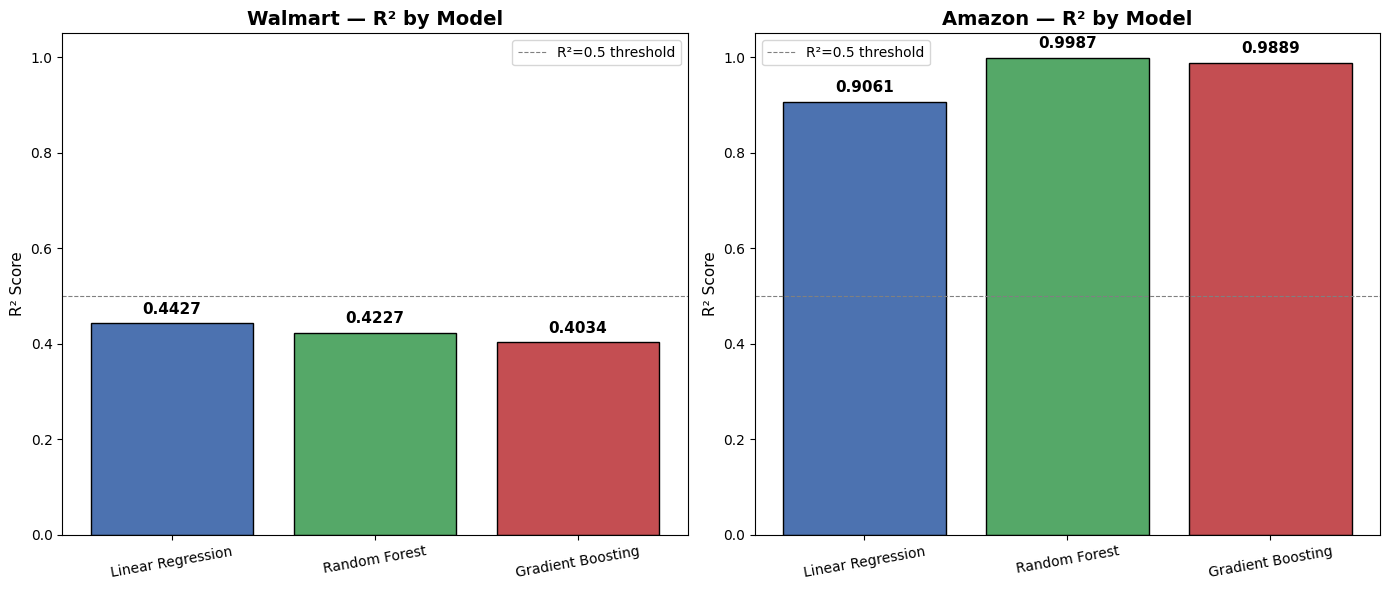

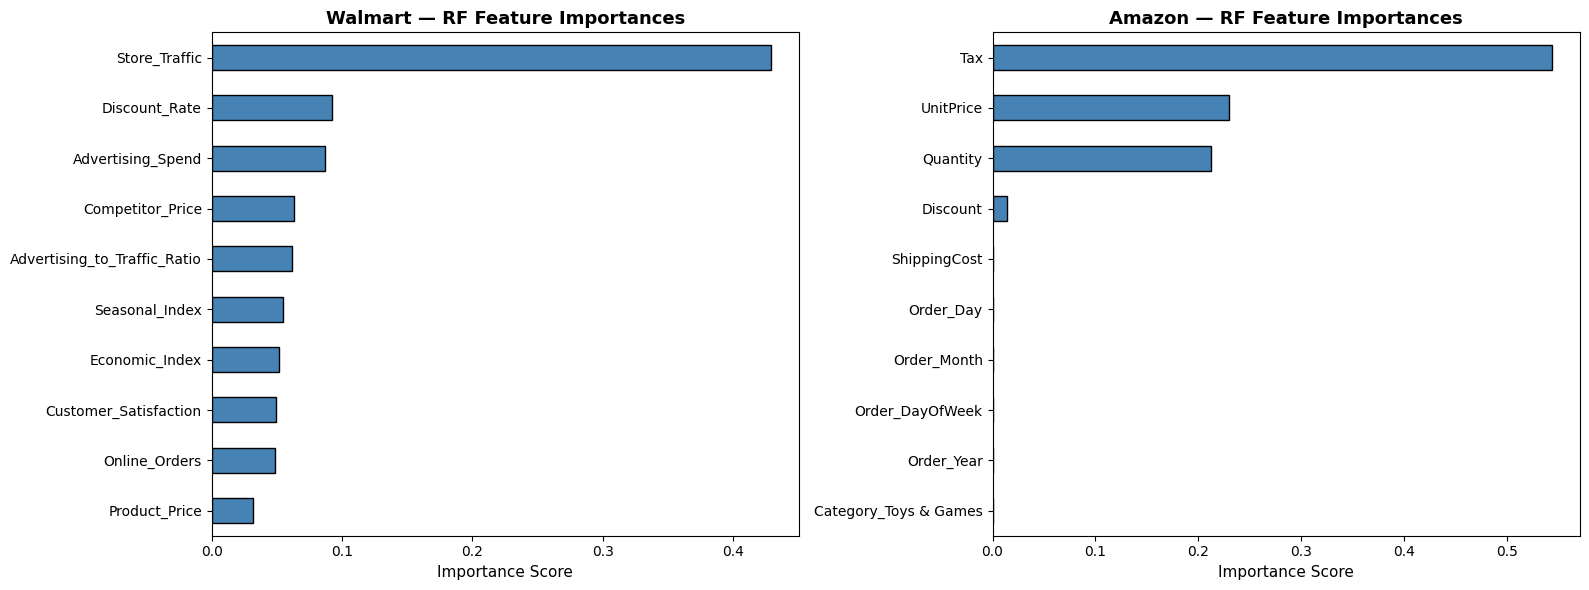

In [36]:
# MODEL EVALUATION: Summary Table

results = {
    'Dataset': [
        'Walmart', 'Walmart', 'Walmart',
        'Amazon',  'Amazon',  'Amazon'
    ],
    'Model': [
        'Linear Regression', 'Random Forest', 'Gradient Boosting',
        'Linear Regression', 'Random Forest', 'Gradient Boosting'
    ],
    'MSE': [
        mse_walmart_fe, mse_rf_walmart, mse_gb_walmart,
        mse_amazon_trans_fe, mse_rf_amazon, mse_gb_amazon
    ],
    'R²': [
        r2_walmart_fe, r2_rf_walmart, r2_gb_walmart,
        r2_amazon_trans_fe, r2_rf_amazon, r2_gb_amazon
    ]
}

results_df = pd.DataFrame(results)
results_df['MSE'] = results_df['MSE'].round(4)
results_df['R²']  = results_df['R²'].round(4)

print("=" * 55)
print("       MODEL COMPARISON SUMMARY")
print("=" * 55)
print(results_df.to_string(index=False))
print("=" * 55)

# Bar Chart: R² by Model and Dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, dataset in zip(axes, ['Walmart', 'Amazon']):
    subset = results_df[results_df['Dataset'] == dataset]
    colors = ['#4C72B0', '#55A868', '#C44E52']
    bars = ax.bar(subset['Model'], subset['R²'], color=colors, edgecolor='black')
    ax.set_title(f'{dataset} — R² by Model', fontsize=14, fontweight='bold')
    ax.set_ylabel('R² Score')
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='R²=0.5 threshold')
    for bar, val in zip(bars, subset['R²']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax.legend()
    ax.set_xticklabels(subset['Model'], rotation=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature Importance (best model on each dataset)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, X, title in zip(
    axes,
    [best_rf_walmart, best_rf_amazon],
    [X_walmart_fe,    X_amazon_fe],
    ['Walmart — RF Feature Importances', 'Amazon — RF Feature Importances']
):
    importances = pd.Series(model.feature_importances_, index=X.columns)
    top10 = importances.nlargest(10).sort_values()
    top10.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

### **Business Interpretation**

 **Walmart Sales Dataset - Model Performance**

All three of the models we ran produced R-squared scores that were in the range 0.40-0.44 which means our features explain 40%-44% of the variation in Walmart's monthly sales volume. In a business context, these figures can tell us a lot about how Walmart handles e-commerce. Their sales volume is difficult to predict, demonstrating the immaturity of its digital sales compared to a company like Amazon that was built specifically for e-commerce.

The Linear Regression slightly outperformed the Random Forest and Gradient Boosting models on Walmart data. That could mean that the relationships between Walmart's features and sales volume are mostly linear which suggests that their advertising and store traffic have a direct and proportional impact on sales outcomes.

**Amazon Transactions Dataset - Model performance**

Amazon's model results are very different. All three of the Amazon models performed much better with Random Forest producing an R-squared score of 0.9987 and Gradient Boosting had a score if 0.9889. The Baseline Linear Regression model also performed well with a score of 0.9061.

Since all three models had such high predictability, we can conclude that Amazon's transaction values are very systematic and formula-driven. We know that Amazon's e-commerce is much more mature and they have managed to algorithmically optimize their infasturcture where pricing, taxes, and discounts follow consistent and predictible rules. If Walmart were to compete at this level, they would need to build similarily systematic and data-driven pricing and discount structures in their e-commerce platforms.

# **Conclusions and Recommendations**

#Conclusions and Recommendations

#Best Model Choice and Why
For the Walmart dataset, the best-performing model on the test set was Linear Regression with an R² of 0.4427, slightly outperforming Random Forest and Gradient Boosting. Although the overall predictive power is moderate, this result suggests that Walmart's sales outcomes in this dataset are influenced by fairly direct relationships among variables such as advertising spend, store traffic, pricing, online orders, and customer satisfaction.

For the Amazon dataset, Random Forest** performed best with an R² of 0.9987. However, this result should be interpreted carefully because Amazon's transaction total is heavily driven by structured pricing variables already included in the dataset, such as quantity, unit price, discount, tax, and shipping cost. In other words, the Amazon model is useful for showing how consistent and system-driven Amazon's transaction process is, but it is less valuable as a strategic forecasting model than the Walmart analysis.

#Business Recommendations
Based on the Walmart results, we recommend that Walmart focus on improving the areas most closely tied to sales performance in its e-commerce operations:

1. Increase precision in advertising spending
   Since advertising appears to have a meaningful relationship with sales, Walmart should invest in more targeted digital campaigns rather than broad spending. This could improve return on ad spend and drive more efficient online growth.

2. Strengthen conversion from traffic to sales
   Store traffic and online order activity both matter, so Walmart should focus on converting visits into purchases through better website design, faster checkout, and more personalized product recommendations.

3. Use more disciplined pricing and discount strategies
   Pricing-related variables clearly influence sales, which suggests Walmart should continue testing optimized discount levels and promotional timing instead of using broad discounting that may reduce margins.

4. Improve customer experience and satisfaction
   Customer satisfaction is likely connected to repeat purchases and stronger e-commerce performance. Walmart should continue improving delivery reliability, ease of ordering, and post-purchase service.

#Suggestions for Next Steps
To strengthen this project in the future, the team could:

- Collect a dataset that is more directly tied to Walmart's online customer behavior, such as website sessions, cart abandonment, delivery times, or regional online sales trends.
- Build a more advanced forecasting model using time-based features or seasonal effects.
- Separate strategic prediction from formula-based transaction prediction, especially in the Amazon dataset.
- Test whether feature engineering works better when done before scaling, since some engineered variables are easier to interpret in their original units.

#Final Takeaway
Overall, this project suggests that Walmart's e-commerce performance can be improved through stronger data-driven decisions around advertising, pricing, traffic conversion, and customer experience. Even though Walmart's predictive results were not as strong as Amazon's, that difference itself is meaningful: it highlights how much more structured and optimized Amazon's e-commerce system appears to be. Walmart can use these insights to close part of that gap and make its digital strategy more consistent and measurable.

# **Final Descriptive Charts**
These charts summarize the main insights from our analysis and will be used in the final presentation. They highlight important business relationships in the Walmart and Amazon datasets, along with a comparison of model performance.

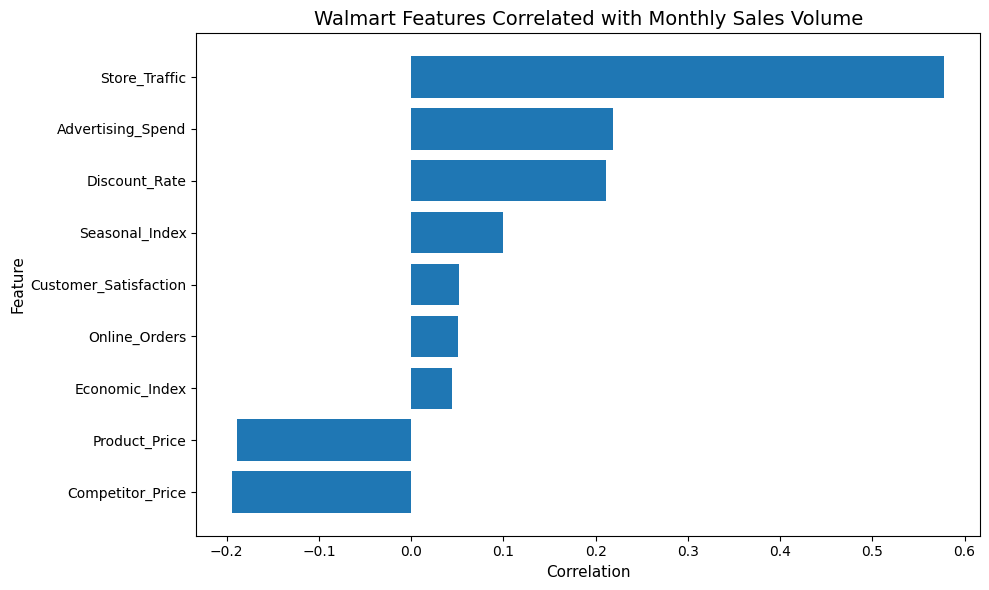

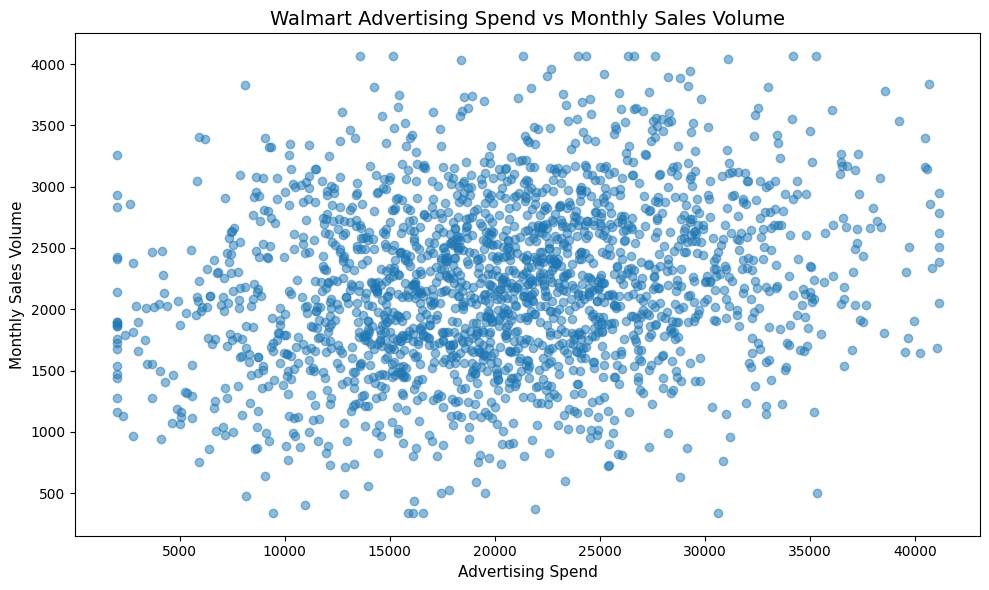

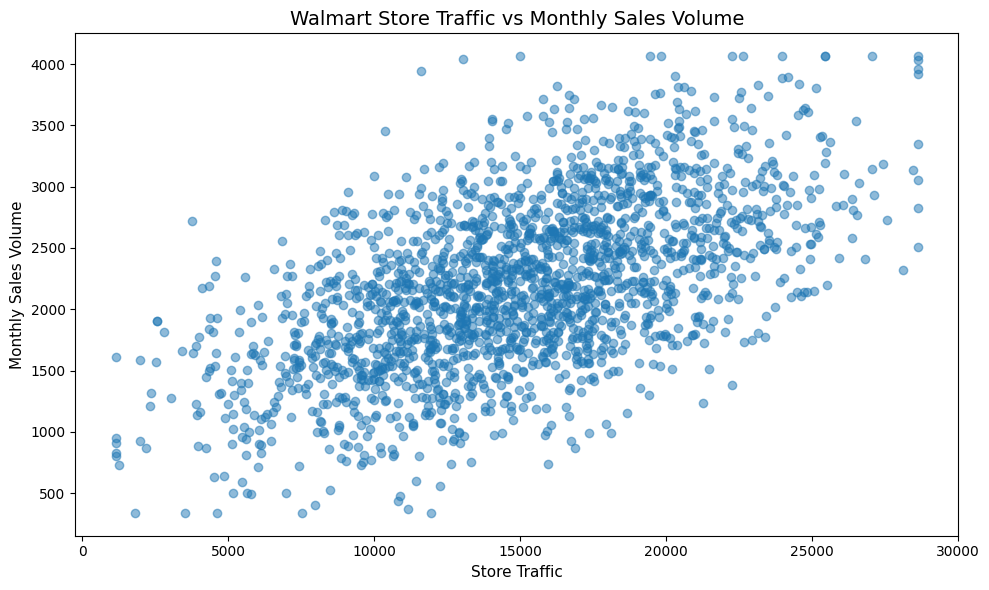

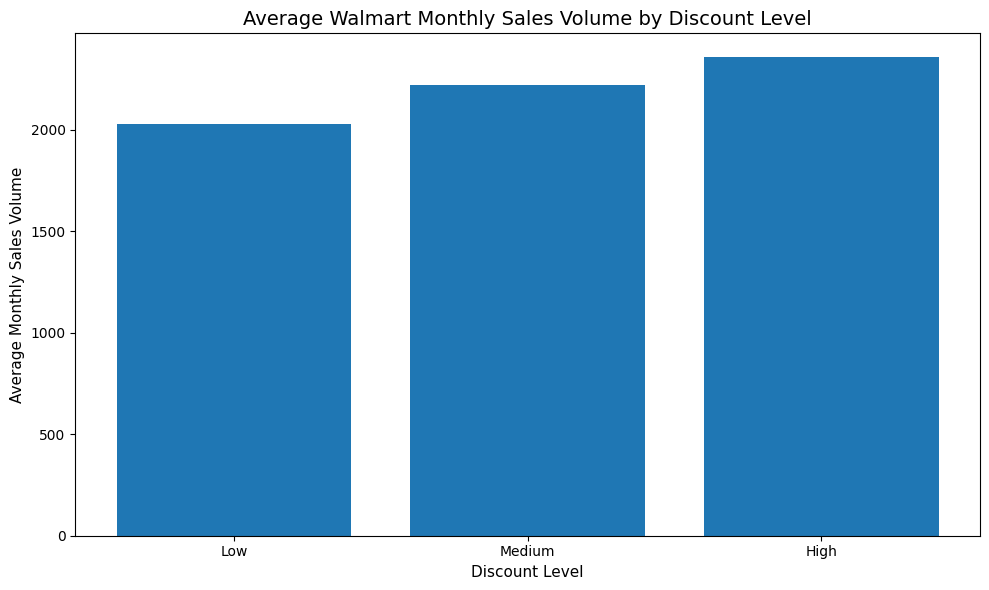

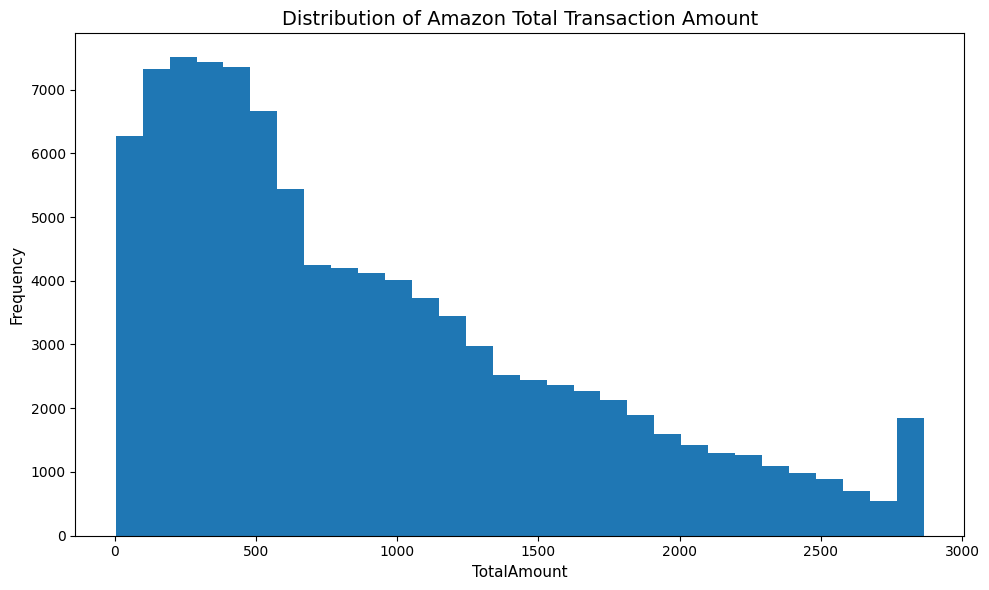

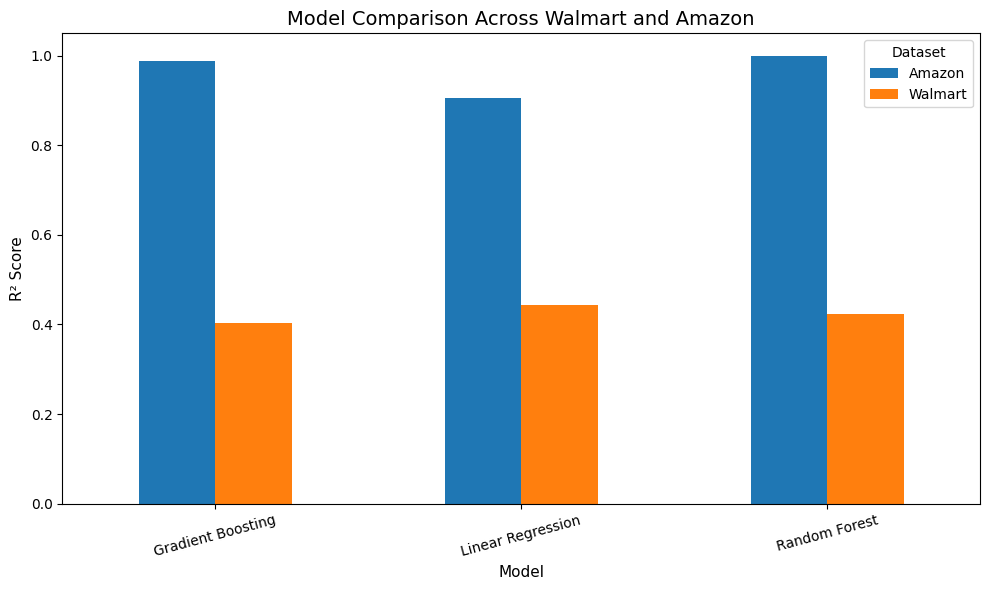

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

# cleaner chart formatting
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

# Chart 1: Walmart correlations with Monthly Sales Volume
walmart_corr = walmart_sales_df.corr(numeric_only=True)['Monthly_Sales_Volume'].drop('Monthly_Sales_Volume')
walmart_corr = walmart_corr.sort_values()

plt.figure()
plt.barh(walmart_corr.index, walmart_corr.values)
plt.title('Walmart Features Correlated with Monthly Sales Volume')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Chart 2: Walmart Advertising Spend vs Monthly Sales Volume
plt.figure()
plt.scatter(walmart_sales_df['Advertising_Spend'], walmart_sales_df['Monthly_Sales_Volume'], alpha=0.5)
plt.title('Walmart Advertising Spend vs Monthly Sales Volume')
plt.xlabel('Advertising Spend')
plt.ylabel('Monthly Sales Volume')
plt.tight_layout()
plt.show()

# Chart 3: Walmart Store Traffic vs Monthly Sales Volume
plt.figure()
plt.scatter(walmart_sales_df['Store_Traffic'], walmart_sales_df['Monthly_Sales_Volume'], alpha=0.5)
plt.title('Walmart Store Traffic vs Monthly Sales Volume')
plt.xlabel('Store Traffic')
plt.ylabel('Monthly Sales Volume')
plt.tight_layout()
plt.show()

# Chart 4: Walmart average sales by discount level
walmart_sales_df['Discount_Level'] = pd.qcut(
    walmart_sales_df['Discount_Rate'],
    q=3,
    labels=['Low', 'Medium', 'High'])

discount_sales = walmart_sales_df.groupby('Discount_Level', observed=False)['Monthly_Sales_Volume'].mean()

plt.figure()
plt.bar(discount_sales.index.astype(str), discount_sales.values)
plt.title('Average Walmart Monthly Sales Volume by Discount Level')
plt.xlabel('Discount Level')
plt.ylabel('Average Monthly Sales Volume')
plt.tight_layout()
plt.show()

# Chart 5: Amazon transaction amount distribution
plt.figure()
plt.hist(amazon_transactions_df['TotalAmount'], bins=30)
plt.title('Distribution of Amazon Total Transaction Amount')
plt.xlabel('TotalAmount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Chart 6: Model comparison across Walmart and Amazon
pivot_r2 = results_df.pivot(index='Model', columns='Dataset', values='R²')

pivot_r2.plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison Across Walmart and Amazon')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()